# Task 1 — LLM-Powered Equity Research Assistant

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/nazifmhd/Task-1---Financial-AI/blob/main/task1_financial/task1_equity_research.ipynb)

**Pipeline:** yfinance OHLCV → five indicators from first principles → multi-source news →
summary dict (**Task 1A**) → per-headline LLM sentiment + reasoned Buy/Hold/Sell with Pydantic
validation (**Task 1B**) → one-page HTML/Markdown brief with embedded matplotlib charts (**Bonus**).

All logic lives in `src/` (data, indicators, news, summary, `llm/`), numbers in `config.py`,
prompts in `src/llm/prompts.py`. This notebook only orchestrates and displays results.

| Section | Rubric item |
|---|---|
| 1 | Setup and key handling (no credentials in code) |
| 2 | 1A: OHLCV fetch (≥2 years, dates computed at runtime) |
| 3 | 1A: Indicators + numerical validation against reference implementations |
| 4 | 1A: News retrieval (≥10 headlines) |
| 5 | 1A: Summary dictionary + robustness demo |
| 6 | 1B: Prompts (system/user separation) |
| 7 | 1B: Per-headline sentiment JSON + aggregation |
| 8 | 1B: Reasoned signal over indicator combinations |
| 9 | 1B: Validation-failure handling demo |
| 10 | Bonus: research brief rendering |

## 1. Setup

In [1]:
# In Colab: clone the repo and install deps. Locally: run from task1_financial/.
import os, sys, subprocess
IN_COLAB = "google.colab" in sys.modules
if IN_COLAB:
    if not os.path.exists("Task-1---Financial-AI"):
        subprocess.run(["git", "clone", "-q", "https://github.com/nazifmhd/Task-1---Financial-AI.git"], check=True)
    os.chdir("Task-1---Financial-AI/task1_financial")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
if os.path.basename(os.getcwd()) != "task1_financial" and os.path.isdir("task1_financial"):
    os.chdir("task1_financial")
sys.path.insert(0, os.getcwd())
print("cwd:", os.getcwd(), "| Colab:", IN_COLAB, "| Python", sys.version.split()[0])

cwd: E:\CDAZZDEV\Task-1---Financial-AI\task1_financial | Colab: False | Python 3.10.7


In [2]:
import json, logging, warnings
import pandas as pd
from IPython.display import display, HTML, Markdown, Image
warnings.filterwarnings("ignore", category=FutureWarning)
logging.basicConfig(level=logging.INFO, format="%(levelname)s %(name)s: %(message)s", force=True)
for noisy in ("httpx", "openai", "yfinance", "urllib3", "matplotlib"):
    logging.getLogger(noisy).setLevel(logging.WARNING)
pd.set_option("display.width", 200); pd.set_option("display.max_columns", 30)
pd.set_option("display.max_colwidth", 100)

import config
from src import data_fetch, indicators, news, summary as summ
from src.llm import client as llm_client, prompts
print("Ticker:", config.TICKER, "| run date:", config.TODAY)

Ticker: NVDA | run date: 2026-10-07


In [3]:
# API key: read from Colab Secrets (key icon in the left sidebar) or a git-ignored .env file.
# The key itself is never printed or stored in the notebook.
try:
    provider, model, _key = llm_client.resolve_provider()
    print(f"LLM provider: {provider} | model: {model} | key loaded: {bool(_key)} (len hidden)")
    del _key
except llm_client.LLMUnavailable as e:
    print("WARNING:", e)

LLM provider: groq | model: openai/gpt-oss-120b | key loaded: True (len hidden)


## 2. Task 1A — OHLCV data (≥ 2 years, no hardcoded dates)
`compute_date_range()` derives `start` from `date.today()` minus `LOOKBACK_YEARS` (2) plus a
300-calendar-day warm-up, so SMA-200 already has valid values at the start of the 2-year window.

In [4]:
start, end = data_fetch.compute_date_range()
print(f"Requested window: {start} -> {end} (computed at runtime)")
raw = data_fetch.fetch_ohlcv(config.TICKER)
span_years = (raw.index[-1] - raw.index[0]).days / 365.25
print(f"{len(raw)} daily bars | {raw.index[0].date()} -> {raw.index[-1].date()} | {span_years:.2f} years")
print("Nulls per column:", raw.isna().sum().to_dict())
assert span_years >= config.LOOKBACK_YEARS
display(raw.tail())

Requested window: 2023-12-12 -> 2026-10-08 (computed at runtime)


INFO src.data_fetch: Fetched 706 daily bars for NVDA (2023-12-12 -> 2026-10-06)


706 daily bars | 2023-12-12 -> 2026-10-06 | 2.82 years
Nulls per column: {'Open': 0, 'High': 0, 'Low': 0, 'Close': 0, 'Volume': 0}


Price,Open,High,Low,Close,Volume
Date,,,,,
2026-09-30,229.270004,232.369995,228.169998,228.380005,121732200
2026-10-01,229.979996,232.289993,228.160004,230.860001,98591400
2026-10-02,236.059998,237.880005,233.600006,233.949997,135167800
2026-10-05,236.089996,240.100006,235.149994,238.899994,127171500
2026-10-06,242.100006,243.369995,238.929993,239.240005,100868800


## 3. Task 1A — Technical indicators from first principles (no TA-Lib)

| Indicator | Implementation (`src/indicators.py`) |
|---|---|
| SMA 50 / 200 | `rolling(n, min_periods=n).mean()` — NaN until a full window exists |
| RSI 14 | **Wilder smoothing**: seed = simple mean of first 14 gains/losses, then `avg = (prev·13 + x)/14`. Edge cases: no losses → 100, flat → 50 |
| MACD 12/26/9 | recursive EMAs (`adjust=False`, α = 2/(n+1)); MACD masked during the 26-bar warm-up; signal = EMA9 of MACD; hist = MACD − signal |
| Bollinger 20/2 | SMA20 ± 2 × **population** std (ddof=0), plus %B and bandwidth |

In [5]:
df = indicators.add_all_indicators(raw)
ind_cols = ["Close", "sma_50", "sma_200", "rsi_14", "macd", "macd_signal", "macd_hist",
            "bb_lower", "bb_mid", "bb_upper", "bb_pct_b"]
print("Warm-up NaNs (expected = window-1):", df[["sma_50", "sma_200", "rsi_14", "macd"]].isna().sum().to_dict())
display(df[ind_cols].tail(8).round(3))

Warm-up NaNs (expected = window-1): {'sma_50': 49, 'sma_200': 199, 'rsi_14': 14, 'macd': 25}


,Close,sma_50,sma_200,rsi_14,macd,macd_signal,macd_hist,bb_lower,bb_mid,bb_upper,bb_pct_b
Date,,,,,,,,,,,
2026-09-25,225.07,215.795,199.127,55.301,2.345,1.974,0.371,210.787,221.655,232.522,0.657
2026-09-28,228.86,216.320,199.349,58.776,2.654,2.110,0.544,211.125,222.232,233.339,0.798
2026-09-29,227.21,216.803,199.568,56.709,2.735,2.235,0.500,211.283,222.566,233.849,0.706
2026-09-30,228.38,217.230,199.807,57.841,2.860,2.360,0.500,211.854,223.125,234.396,0.733
2026-10-01,230.86,217.611,200.089,60.216,3.123,2.513,0.611,211.698,223.460,235.222,0.815
2026-10-02,233.95,218.119,200.379,63.011,3.541,2.718,0.822,211.277,223.748,236.219,0.909
2026-10-05,238.90,218.765,200.687,67.010,4.222,3.019,1.203,210.310,224.188,238.066,1.030
2026-10-06,239.24,219.624,201.031,67.272,4.735,3.362,1.373,209.524,224.876,240.228,0.968


### 3.1 Indicator validation
Each indicator is checked on the **real** price series against an independent, loop-based
implementation of the textbook formula (written separately in `tests/test_indicators.py`).
We also show that a naïve rolling-mean RSI differs materially — the common error the rubric warns about.

In [6]:
import numpy as np, math
from tests.test_indicators import ref_sma, ref_rsi, ref_ema

x = df["Close"].tolist()
checks = {}
checks["SMA-50"]  = np.nanmax(np.abs(df["sma_50"].to_numpy() - np.array(ref_sma(x, 50))))
checks["SMA-200"] = np.nanmax(np.abs(df["sma_200"].to_numpy() - np.array(ref_sma(x, 200))))
checks["RSI-14 (Wilder)"] = np.nanmax(np.abs(df["rsi_14"].to_numpy() - np.array(ref_rsi(x, 14))))
line = np.array(ref_ema(x, 12)) - np.array(ref_ema(x, 26))
checks["MACD line"] = np.nanmax(np.abs(df["macd"].to_numpy()[25:] - line[25:]))
i = len(x) - 1; w = x[i-19:i+1]; mu = sum(w)/20; sd = math.sqrt(sum((v-mu)**2 for v in w)/20)
checks["Bollinger upper (last bar)"] = abs(df["bb_upper"].iloc[-1] - (mu + 2*sd))
display(pd.DataFrame({"max abs error vs reference": {k: f"{v:.2e}" for k, v in checks.items()}}))

d = df["Close"].diff()
naive = 100 - 100 / (1 + d.clip(lower=0).rolling(14).mean() / (-d.clip(upper=0)).rolling(14).mean())
print(f"Last-bar RSI  Wilder: {df['rsi_14'].iloc[-1]:.2f}  |  naive rolling-mean RSI: {naive.iloc[-1]:.2f}"
      f"  |  max divergence over history: {(df['rsi_14'] - naive).abs().max():.1f} pts")

,max abs error vs reference
Bollinger upper (last bar),3.95e-12
MACD line,0.00e+00
RSI-14 (Wilder),0.00e+00
SMA-200,0.00e+00
SMA-50,0.00e+00


Last-bar RSI  Wilder: 67.27  |  naive rolling-mean RSI: 84.04  |  max divergence over history: 27.6 pts


In [7]:
# Full unit-test suite: indicators vs references, edge cases, LLM validation/repair logic.
import subprocess, sys
r = subprocess.run([sys.executable, "-m", "pytest", "-q", "--no-header", "-p", "no:cacheprovider"],
                   capture_output=True, text=True)
print(r.stdout[-1500:] or r.stderr[-1500:])

...............                                                          [100%]
15 passed in 1.13s



## 4. Task 1A — News headlines (≥ 10, free sources)
Sources are layered and each is isolated in its own `try/except`: yfinance `.news` (its schema
changed in 2024 and often returns nothing) → Yahoo Finance RSS → Google News RSS. Results are
de-duplicated and **ranked**: company-specific news first, auto-generated 13F holding-change
headlines ("X LLC buys 2,218 shares of …") next, generic market pieces last.

In [8]:
fundamentals = data_fetch.fetch_fundamentals(config.TICKER)
headlines = news.get_news(config.TICKER, company=fundamentals["company_name"])
print(f"{len(headlines)} headlines retrieved (minimum {config.MIN_HEADLINES})")
assert len(headlines) >= config.MIN_HEADLINES
display(pd.DataFrame(headlines)[["published", "source", "publisher", "relevant", "boilerplate", "title"]])

INFO src.news: Retrieved 15 headlines for NVDA (15 company-specific, from 118 unique candidates)


15 headlines retrieved (minimum 10)


,published,source,publisher,relevant,boilerplate,title
0,2026-10-07T11:07:37+00:00,google_news_rss,GuruFocus,True,False,Dan Ives Highlights Nvidia (NVDA) as Top Tech Stock Amid $4T Spe
1,2026-10-07T10:50:00+00:00,yahoo_rss,Yahoo Finance,True,False,This 1 Quote in Anthropic's IPO Prospectus Should Have AI Investors Buying More Nvidia Stock
2,2026-10-07T10:15:00+00:00,yahoo_rss,Yahoo Finance,True,False,"Forget Nvidia and AMD, This Under-the-Radar Chip Stock Could Win the AI Semiconductor Race"
3,2026-10-07T10:09:37+00:00,yahoo_rss,Yahoo Finance,True,False,"SpaceX Seeks $40 Billion Financing for Nvidia Chips, FT Reports"
4,2026-10-07T04:23:09+00:00,google_news_rss,Stocktwits,True,False,"Why NVDA, AMD, CRWD Stocks Surged To 52-Week Highs Today"
5,2026-10-07T03:21:18+00:00,google_news_rss,GuruFocus,True,False,"AI Giants Drive Market Rally: Nvidia (NVDA), Microsoft (MSFT), M"
6,2026-10-07T03:14:36+00:00,google_news_rss,Benzinga,True,False,Nvidia Stock Price Target Splits Crypto Punters: Here's Where They See the Chip Giant Going in O...
7,2026-10-07T02:15:00+00:00,google_news_rss,The Motley Fool,True,False,Nvidia Hits a New All-Time High. Is the AI Stock a Buy?
8,2026-10-07T01:49:00+00:00,google_news_rss,Yahoo Finance,True,False,SpaceX Stock Drops After Hours as Elon Musk-led Company Seeks $40 Billion to Buy Nvidia Chips
9,2026-10-07T00:32:09+00:00,google_news_rss,Stocktwits,True,False,"NVDA Stock Bucks Selloff Premarket On SpaceX Boost, Foxconn’s Sales Update"


## 5. Task 1A — Summary dictionary

In [9]:
summary = summ.build_summary(df, fundamentals, config.TICKER)
print(json.dumps(summary, indent=2, default=str))
required = ["current_price", "week52_high", "week52_low", "pe_ratio", "ytd_return_pct", "momentum_signal"]
print("All required fields present:", all(k in summary for k in required))

{
  "ticker": "NVDA",
  "company_name": "NVIDIA Corporation",
  "sector": "Technology",
  "as_of": "2026-10-06",
  "current_price": 239.24,
  "week52_high": 243.37,
  "week52_low": 163.9,
  "week52_source": "ohlcv",
  "pct_from_52w_high": -1.7,
  "pe_ratio": 30.25,
  "forward_pe": 15.14,
  "ytd_return_pct": 28.58,
  "momentum_signal": "bullish",
  "momentum_detail": {
    "label": "bullish",
    "score": "5/5",
    "checks": {
      "price_above_sma50": true,
      "sma50_above_sma200": true,
      "macd_above_signal": true,
      "macd_hist_rising": true,
      "rsi_bullish_not_overbought": true
    }
  }
}
All required fields present: True


### 5.1 Robustness: invalid ticker and missing data
A non-existent ticker and a frame with injected gaps must degrade gracefully (logged warnings,
`None` fields) — never raise.

In [10]:
bad = summ.run_task1a("ZZZZ-NOT-A-TICKER")
print("Bars:", len(bad.prices), "| headlines:", len(bad.headlines))
print(json.dumps({k: bad.summary[k] for k in ["current_price", "week52_high", "pe_ratio",
                                              "ytd_return_pct", "momentum_signal"]}, indent=1))

gappy = raw.copy()
gappy.iloc[-30:-25, gappy.columns.get_loc("Close")] = np.nan     # inject missing closes
gappy.iloc[-10:, gappy.columns.get_loc("Volume")] = np.nan
g = indicators.add_all_indicators(gappy.ffill())
print("With gaps -> momentum:", indicators.momentum_signal(g)["label"],
      "| last RSI:", round(g["rsi_14"].iloc[-1], 2))
print("Empty frame -> summary:", summ.build_summary(pd.DataFrame(), {}, "EMPTY")["momentum_signal"])

ERROR yfinance: HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ZZZZ-NOT-A-TICKER"}}}


ERROR yfinance: 
1 Failed download:


ERROR yfinance: ['ZZZZ-NOT-A-TICKER']: YFTzMissingError('possibly delisted; no timezone found')


WARNING src.data_fetch: No OHLCV returned for ZZZZ-NOT-A-TICKER


ERROR yfinance: HTTP Error 404: {"quoteSummary":{"result":null,"error":{"code":"Not Found","description":"Quote not found for symbol: ZZZZ-NOT-A-TICKER"}}}


WARNING src.news: Only 3 headlines retrieved for ZZZZ-NOT-A-TICKER (wanted 10)


WARNING src.summary: Empty price frame - summary will be mostly null


WARNING src.summary: Empty price frame - summary will be mostly null


Bars: 0 | headlines: 3
{
 "current_price": null,
 "week52_high": null,
 "pe_ratio": null,
 "ytd_return_pct": null,
 "momentum_signal": "insufficient_data"
}
With gaps -> momentum: bullish | last RSI: 69.96
Empty frame -> summary: insufficient_data


In [11]:
# Single orchestrator used by the rest of the notebook (same results as the steps above).
task1a = summ.run_task1a(config.TICKER)
print(json.dumps(task1a.summary, default=str)[:400], "...")

INFO src.data_fetch: Fetched 706 daily bars for NVDA (2023-12-12 -> 2026-10-06)


INFO src.news: Retrieved 15 headlines for NVDA (15 company-specific, from 117 unique candidates)


{"ticker": "NVDA", "company_name": "NVIDIA Corporation", "sector": "Technology", "as_of": "2026-10-06", "current_price": 239.24, "week52_high": 243.37, "week52_low": 163.9, "week52_source": "ohlcv", "pct_from_52w_high": -1.7, "pe_ratio": 30.25, "forward_pe": 15.14, "ytd_return_pct": 28.58, "momentum_signal": "bullish", "momentum_detail": {"label": "bullish", "score": "5/5", "checks": {"price_above ...


## 6. Task 1B — Prompt engineering
Prompts are versioned constants in `src/llm/prompts.py` — no prompt text is built inline in business
logic. **System** messages hold persona, rules and the output contract; **user** messages carry only
per-call data. The signal system prompt explicitly forbids restating values and requires reasoning
about how indicators *interact* and weighing at least one conflicting signal.

In [12]:
print("PROMPT_VERSION:", prompts.PROMPT_VERSION)
print("=" * 30, "SENTIMENT_SYSTEM", "=" * 30); print(prompts.SENTIMENT_SYSTEM)
print("=" * 30, "SIGNAL_SYSTEM", "=" * 30); print(prompts.SIGNAL_SYSTEM)

PROMPT_VERSION: 1.0.0
============================== SENTIMENT_SYSTEM ==============================
You are a sell-side equity research assistant classifying news headlines.

Task: judge the likely short-term impact of ONE headline on the share price of
the target company named by the user (not on the market in general).

Rules:
- "positive": the headline implies better prospects, demand, earnings,
  guidance, upgrades or favourable deals for the target company.
- "negative": it implies weaker prospects, legal/regulatory trouble,
  downgrades, competitive losses, supply problems or selling pressure.
- "neutral": routine, ambiguous, mainly about another company, generic
  market commentary, or institutional position changes (13F filings).
- confidence is your probability (0.0-1.0) that the label is correct. Use
  <= 0.6 when the headline is ambiguous or only indirectly about the company.
- brief_reason: one sentence, <= 25 words, naming the mechanism.
- Copy the headline verbatim into 

## 7. Task 1B — Per-headline sentiment (structured JSON) + aggregation
One LLM call per headline; each reply is validated against `HeadlineSentiment`
(`headline`, `sentiment ∈ {positive, negative, neutral}`, `confidence ∈ [0,1]`, `brief_reason`).

**Aggregate** = Σ(polarity × confidence) / Σ(confidence) ∈ [−1, 1], with a ±0.15 neutral dead-band.
Confidence-weighting means a hesitant call cannot cancel a confident one; neutral items stay in the
denominator so routine news dilutes the score; headlines that never validated are **excluded and
counted**, not silently defaulted to neutral.

In [13]:
from src.llm.sentiment import score_headlines
sentiment = score_headlines(task1a.headlines, task1a.ticker, task1a.summary["company_name"])
print("Per-headline JSON (first 3):")
for h in sentiment.per_headline[:3]:
    print(h.model_dump_json(indent=2))

INFO llm: LLM client ready: provider=groq model=openai/gpt-oss-120b


INFO src.llm.sentiment: Sentiment: positive (0.622) from 15/15 headlines


Per-headline JSON (first 3):
{
  "headline": "Dan Ives Highlights Nvidia (NVDA) as Top Tech Stock Amid $4T Spe",
  "sentiment": "positive",
  "confidence": 0.92,
  "brief_reason": "Analyst endorsement as top tech stock signals strong demand and likely lifts the share price."
}
{
  "headline": "This 1 Quote in Anthropic's IPO Prospectus Should Have AI Investors Buying More Nvidia Stock",
  "sentiment": "positive",
  "confidence": 0.92,
  "brief_reason": "Prospectus praise signals strong demand for Nvidia chips, likely spurring buying pressure on the stock."
}
{
  "headline": "Forget Nvidia and AMD, This Under-the-Radar Chip Stock Could Win the AI Semiconductor Race",
  "sentiment": "negative",
  "confidence": 0.78,
  "brief_reason": "Implies a competitor may outpace Nvidia in AI chips, lowering growth expectations for Nvidia."
}


In [14]:
display(pd.DataFrame([h.model_dump() for h in sentiment.per_headline]))
print(json.dumps({k: v for k, v in sentiment.model_dump().items() if k != "per_headline"}, indent=2))

,headline,sentiment,confidence,brief_reason
0,Dan Ives Highlights Nvidia (NVDA) as Top Tech Stock Amid $4T Spe,positive,0.92,Analyst endorsement as top tech stock signals strong demand and likely lifts the share price.
1,This 1 Quote in Anthropic's IPO Prospectus Should Have AI Investors Buying More Nvidia Stock,positive,0.92,"Prospectus praise signals strong demand for Nvidia chips, likely spurring buying pressure on the..."
2,"Forget Nvidia and AMD, This Under-the-Radar Chip Stock Could Win the AI Semiconductor Race",negative,0.78,"Implies a competitor may outpace Nvidia in AI chips, lowering growth expectations for Nvidia."
3,"SpaceX Seeks $40 Billion Financing for Nvidia Chips, FT Reports",positive,0.86,"Huge financing request signals strong demand for Nvidia chips, boosting short‑term sales outlook."
4,"Why NVDA, AMD, CRWD Stocks Surged To 52-Week Highs Today",positive,0.92,A 52‑week high indicates strong buying pressure and positive market sentiment toward NVIDIA.
5,"AI Giants Drive Market Rally: Nvidia (NVDA), Microsoft (MSFT), M",positive,0.73,Rally tied to AI demand suggests stronger investor optimism for Nvidia's AI-related growth.
6,Nvidia Stock Price Target Splits Crypto Punters: Here's Where They See the Chip Giant Going in O...,neutral,0.55,Analyst price target divergence signals uncertainty but no clear catalyst for price movement.
7,Nvidia Hits a New All-Time High. Is the AI Stock a Buy?,positive,0.75,"All‑time high signals strong demand and market optimism, likely supporting short‑term price gains."
8,SpaceX Stock Drops After Hours as Elon Musk-led Company Seeks $40 Billion to Buy Nvidia Chips,neutral,0.58,"Main focus is SpaceX’s stock move; Nvidia is only mentioned as a potential buyer, so impact on i..."
9,"NVDA Stock Bucks Selloff Premarket On SpaceX Boost, Foxconn’s Sales Update",positive,0.82,Positive demand signals from SpaceX and Foxconn suggest stronger near‑term revenue for NVIDIA.


{
  "aggregate_score": 0.622,
  "aggregate_label": "positive",
  "counts": {
    "positive": 10,
    "neutral": 3,
    "negative": 2
  },
  "n_scored": 15,
  "n_total": 15,
  "n_failed": 0
}


## 8. Task 1B — Reasoned Buy / Hold / Sell
`build_signal_context()` turns raw indicator levels into **relationships** (distance from each SMA,
crossover recency, histogram slope, RSI change, %B, bandwidth percentile, volume ratio) so the
model can reason about interactions. Output is validated as `TradeSignal` (enum signal,
3–5-sentence justification counted with a decimal-safe sentence splitter, 2–4 key drivers).

In [15]:
from src.llm.signal import generate_signal
sig = generate_signal(task1a.prices, task1a.summary, sentiment)
print("USER PROMPT SENT TO THE MODEL:\n" + sig["prompt"])

USER PROMPT SENT TO THE MODEL:
Stock: NVIDIA Corporation (NVDA), sector: Technology
Snapshot as of: 2026-10-06

Trend
- Close: 239.24
- SMA-50: 219.62 (price +8.9% vs SMA-50)
- SMA-200: 201.03 (price +19.0% vs SMA-200)
- SMA regime: bullish (SMA-50 above SMA-200); last 50/200 crossover: golden cross 320 sessions ago (2025-06-27)
- Returns: 1-month +4.0%, 3-month +17.3%, YTD +28.6%
- Distance from 52-week high: -1.7%

Momentum
- RSI(14): 67.3 (5 sessions ago: 56.7)
- MACD(12,26,9): line 4.735, signal 3.362, histogram +1.373
  (histogram rising over the last 3 sessions);
  last MACD/signal crossover: bullish cross 10 sessions ago (2026-09-22)

Volatility
- Bollinger(20,2): upper 240.23, middle 224.88, lower 209.52
- %B: 0.97 (0 = lower band, 1 = upper band)
- Bandwidth: 0.137 (percentile vs. last year: 68th)
- Volume vs 20-day average: 0.93x

Rule-based momentum vote (5 checks): bullish (5/5)

News sentiment (LLM, confidence-weighted over 15 headlines):
positive, score +0.622 on a -1..+1

In [16]:
s = sig["signal"]
print(f"SOURCE: {sig['source']}  |  SIGNAL: {s.signal}  |  CONVICTION: {s.conviction}\n")
print("JUSTIFICATION:\n" + s.justification + "\n")
print("KEY DRIVERS:", *[f"  - {d}" for d in s.key_drivers], sep="\n")
print("CONFLICTING SIGNALS:", *[f"  - {d}" for d in s.conflicting_signals], sep="\n")

SOURCE: llm  |  SIGNAL: Buy  |  CONVICTION: medium

JUSTIFICATION:
The price is firmly above both the 50‑day and 200‑day SMAs, confirming a sustained bullish regime, while the MACD line sits above its signal with a rising histogram, reinforcing upward momentum. RSI has climbed to 67, indicating strong but not yet exhausted buying pressure, and the positive news sentiment adds fundamental support. However, the stock is trading near the upper Bollinger band and just 1.7% below its 52‑week high, suggesting a short‑term overextension, and volume is slightly below its 20‑day average, hinting at waning participation. Overall, the bullish trend and momentum outweigh these near‑term cautions, supporting a buy recommendation for the next 1‑3 months.

KEY DRIVERS:
  - price above SMA‑50/200 confirming bullish trend
  - MACD histogram rising with bullish crossover supporting momentum
  - RSI climbing yet below overbought within uptrend
  - Bollinger %B near upper band indicating potential short‑t

### 8.1 Reviewer note: does the model reason over combinations? (run of 2026-10-07)

The output is not a list of indicator values. It **combines** them in several places:

| Interaction in the justification | Why it is combination reasoning |
|---|---|
| *"price firmly above both the 50-day and 200-day SMAs … while the MACD line sits above its signal with a rising histogram"* | Treats the trend regime and MACD momentum as **mutually confirming**, not as two separate facts. |
| *"RSI has climbed to 67, indicating strong but not yet exhausted buying pressure"* | Reads RSI **in the context of the uptrend** (67 counts as confirmation inside a bullish regime), which is the regime-conditional reading the system prompt asks for. It also uses the 5-session change (56.7 → 67.3). |
| *"trading near the upper Bollinger band and just 1.7% below its 52-week high … volume slightly below its 20-day average, hinting at waning participation"* | Weighs **conflicting evidence**: price stretch (%B 0.97) and soft volume (0.93×) against the trend. It concludes these are near-term cautions, which is why conviction is *medium* rather than *high*. |
| *"positive news sentiment adds … support"* | Uses the LLM news aggregate (+0.62) as **confirmation** of the technical picture rather than a separate verdict. |

The structured `key_drivers` and `conflicting_signals` fields make this reasoning auditable. Note
that the model did **not** just copy the rule-based vote (5/5 bullish → Buy). It lowered conviction
because of the Bollinger stretch, the proximity to the 52-week high and the volume, none of which
the rule-based vote looks at.

*Limitation:* the call is purely technical plus headline sentiment. Valuation (trailing P/E ≈ 30)
and macro risk are outside its inputs (see REFLECTION.md).

## 9. Task 1B — Structured-output validation failures are caught, logged, and handled
A fake OpenAI-compatible transport injects realistic failures (prose instead of JSON, an
out-of-enum label, an out-of-range confidence). The client logs each failure, feeds the
validation error back to the model, retries (max 2), and finally returns `None`, which the
aggregator excludes and counts.

In [17]:
from types import SimpleNamespace
from src.llm.client import LLMClient, VALIDATION_EVENTS
from src.llm.schemas import HeadlineSentiment

class ScriptedTransport:
    def __init__(self, replies): self.replies = list(replies)
    def create(self, **kw):
        msg = SimpleNamespace(content=self.replies.pop(0))
        return SimpleNamespace(choices=[SimpleNamespace(message=msg)])

ok = '{"headline": "%s", "sentiment": "negative", "confidence": 0.8, "brief_reason": "Export curbs hit revenue."}'
VALIDATION_EVENTS.clear()
scripted = LLMClient(transport=ScriptedTransport([
    # headline A: prose, then wrong enum, then valid  -> recovered on attempt 3
    "Sure! The sentiment is clearly bearish.",
    '{"headline": "A", "sentiment": "bearish", "confidence": 0.8, "brief_reason": "x y z"}',
    ok % "A",
    # headline B: three invalid replies -> excluded
    '{"headline": "B", "sentiment": "positive", "confidence": 1.7, "brief_reason": "too sure"}',
    '{"headline": "B", "sentiment": "mixed", "confidence": 0.5, "brief_reason": "unsure"}',
    "```json\n{ broken json\n```",
    # headline C: valid first time
    '{"headline": "C", "sentiment": "positive", "confidence": 0.9, "brief_reason": "Record data-center sales."}',
]))
demo = score_headlines([{"title": t} for t in "ABC"], "DEMO", "Demo Corp", client=scripted)
print(f"\nscored={demo.n_scored} failed={demo.n_failed} aggregate={demo.aggregate_score:+.3f} ({demo.aggregate_label})")
display(pd.DataFrame(VALIDATION_EVENTS))

INFO llm: LLM client ready: provider=fake model=fake-model


WARNING llm: [headline_sentiment] validation failed (attempt 1/3): no JSON object found in response


WARNING llm: [headline_sentiment] validation failed (attempt 2/3): sentiment: Input should be 'positive', 'negative' or 'neutral'


WARNING llm: [headline_sentiment] validation failed (attempt 1/3): confidence: Input should be less than or equal to 1


WARNING llm: [headline_sentiment] validation failed (attempt 2/3): sentiment: Input should be 'positive', 'negative' or 'neutral'


...

ERROR llm: [headline_sentiment] giving up after 3 attempts - result excluded


WARNING src.llm.sentiment: Excluded from aggregate (no valid output): B


INFO src.llm.sentiment: Sentiment: neutral (0.059) from 2/3 headlines



scored=2 failed=1 aggregate=+0.059 (neutral)


,task,attempt,error,raw
0,headline_sentiment,1,no JSON object found in response,Sure! The sentiment is clearly bearish.
1,headline_sentiment,2,"sentiment: Input should be 'positive', 'negative' or 'neutral'","{""headline"": ""A"", ""sentiment"": ""bearish"", ""confidence"": 0.8, ""brief_reason"": ""x y z""}"
2,headline_sentiment,1,confidence: Input should be less than or equal to 1,"{""headline"": ""B"", ""sentiment"": ""positive"", ""confidence"": 1.7, ""brief_reason"": ""too sure""}"
3,headline_sentiment,2,"sentiment: Input should be 'positive', 'negative' or 'neutral'","{""headline"": ""B"", ""sentiment"": ""mixed"", ""confidence"": 0.5, ""brief_reason"": ""unsure""}"
4,headline_sentiment,3,no JSON object found in response,```json\n{ broken json\n```


In [18]:
# The same machinery on the live model: every real call is audited to outputs/llm_calls.jsonl
audit = pd.read_json(llm_client.AUDIT_LOG_PATH, lines=True)
live = audit[audit["model"] != "fake-model"]
print(f"Live LLM attempts: {len(live)} | first-try validation success: {live['ok'].mean():.0%}")
display(live.groupby("task")[["ok", "latency_s"]].agg(["count", "mean"]).round(3))

Live LLM attempts: 16 | first-try validation success: 100%


ok      latency_s       
                   count mean     count   mean
task                                          
headline_sentiment    15  1.0        15  1.175
trade_signal           1  1.0         1  2.120

## 10. Bonus — One-page equity research brief

In [19]:
from src.pipeline import Task1BResult, save_outputs
import report
model_name = f"{provider}/{model}" if "provider" in dir() else "unavailable"
task1b = Task1BResult(sentiment=sentiment, signal=sig, llm_model=model_name)
print(json.dumps(save_outputs(task1a, task1b), indent=1))
paths = report.render(task1a, task1b)
print(json.dumps(paths, indent=1))

{
 "summary": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\summary.json",
 "headlines": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\headlines.json",
 "sentiment": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\sentiment.json",
 "signal": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\signal.json",
 "prices": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\prices_with_indicators.csv"
}


INFO report: PDF not rendered (HTML is the primary output): No module named 'weasyprint'


{
 "chart": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\chart.png",
 "sentiment_chart": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\sentiment.png",
 "markdown": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\brief.md",
 "html": "E:\\CDAZZDEV\\Task-1---Financial-AI\\task1_financial\\outputs\\brief.html"
}


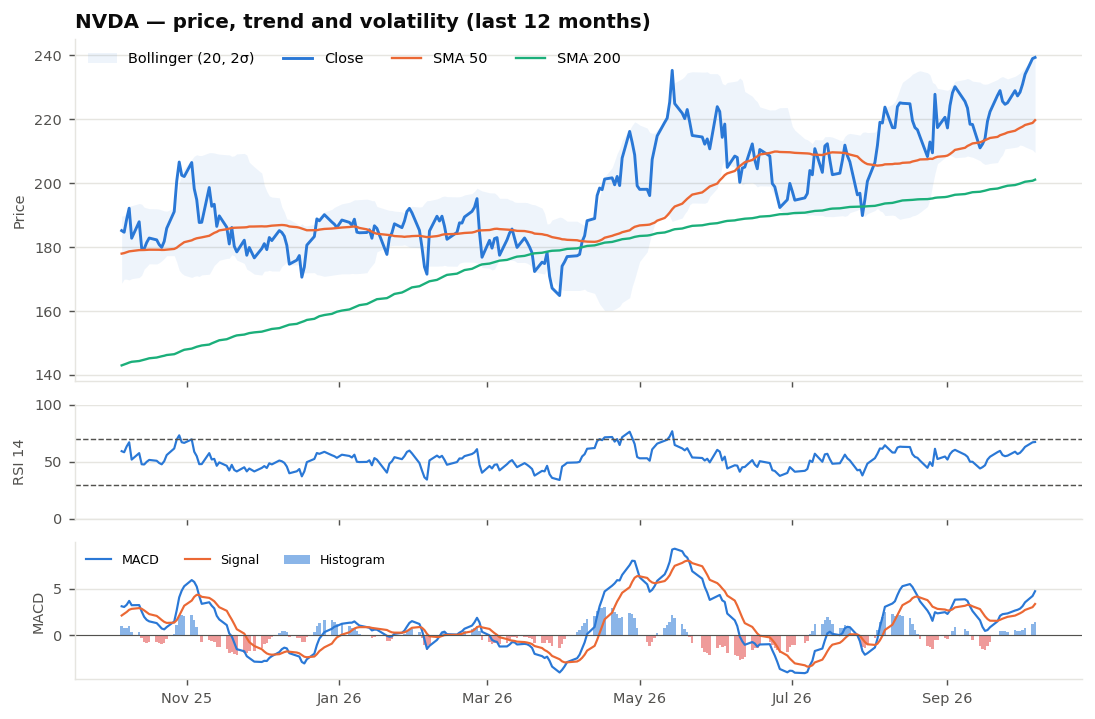

In [20]:
display(Image(filename=paths["chart"]))

In [21]:
display(Markdown(open(paths["markdown"], encoding="utf-8").read().replace("](chart.png)", "](outputs/chart.png)")))

# NVIDIA Corporation (NVDA) — Equity Research Brief
*Data as of 2026-10-06 · generated 2026-10-07 · model `groq/openai/gpt-oss-120b` · prompts v1.0.0*

## Recommendation: **BUY** (medium conviction)
The price is firmly above both the 50‑day and 200‑day SMAs, confirming a sustained bullish regime, while the MACD line sits above its signal with a rising histogram, reinforcing upward momentum. RSI has climbed to 67, indicating strong but not yet exhausted buying pressure, and the positive news sentiment adds fundamental support. However, the stock is trading near the upper Bollinger band and just 1.7% below its 52‑week high, suggesting a short‑term overextension, and volume is slightly below its 20‑day average, hinting at waning participation. Overall, the bullish trend and momentum outweigh these near‑term cautions, supporting a buy recommendation for the next 1‑3 months.

**Key drivers:** price above SMA‑50/200 confirming bullish trend; MACD histogram rising with bullish crossover supporting momentum; RSI climbing yet below overbought within uptrend; Bollinger %B near upper band indicating potential short‑term pullback
**Conflicting signals:** price hugging upper Bollinger band; RSI approaching overbought levels; volume below 20‑day average

## Company snapshot
| Metric | Value |
|---|---|
| Sector | Technology |
| Current price | $239.24 |
| 52-week range | $163.90 – $243.37 (-1.70% from high) |
| P/E (trailing / forward) | 30.25 / 15.14 |
| YTD return | +28.58% |
| Momentum signal | bullish (5/5) |

## Technical outlook
| Indicator | Value |
|---|---|
| SMA 50 / SMA 200 | $219.62 / $201.03 |
| RSI(14) | 67.3 |
| MACD / signal / hist | 4.735 / 3.362 / 1.373 |
| Bollinger lower / mid / upper | $209.52 / $224.88 / $240.23 |
| Bollinger %B | 0.97 |

![Price and indicators](outputs/chart.png)

## News sentiment: positive (+0.622)
Scored 15/15 headlines — 10 positive, 3 neutral, 2 negative.

**Top 3 headlines**

1. *Dan Ives Highlights Nvidia (NVDA) as Top Tech Stock Amid $4T Spe* — **positive** (0.92): Analyst endorsement as top tech stock signals strong demand and likely lifts the share price.
2. *This 1 Quote in Anthropic's IPO Prospectus Should Have AI Investors Buying More Nvidia Stock* — **positive** (0.92): Prospectus praise signals strong demand for Nvidia chips, likely spurring buying pressure on the stock.
3. *Why NVDA, AMD, CRWD Stocks Surged To 52-Week Highs Today* — **positive** (0.92): A 52‑week high indicates strong buying pressure and positive market sentiment toward NVIDIA.

---
**Risk disclaimer.** This brief was generated automatically by an LLM-assisted research pipeline for a technical assessment. It is not investment advice, an offer or a solicitation to buy or sell any security. Technical indicators are backward-looking, news sentiment is model-estimated and may be wrong, and the recommendation ignores valuation, fundamentals, macro conditions and your personal circumstances. Markets involve risk, including loss of principal. Verify all data independently and consult a licensed adviser before making any investment decision.

Indicator,Latest
SMA 50 / SMA 200,$219.62 / $201.03
"RSI (14, Wilder)",67.3
MACD / signal / hist,4.73 / 3.36 / 1.37
Bollinger L / M / U,209.52 / 224.88 / 240.23
Bollinger %B,0.97
Momentum check,Result
price above sma50,yes
sma50 above sma200,yes
macd above signal,yes
macd hist rising,yes

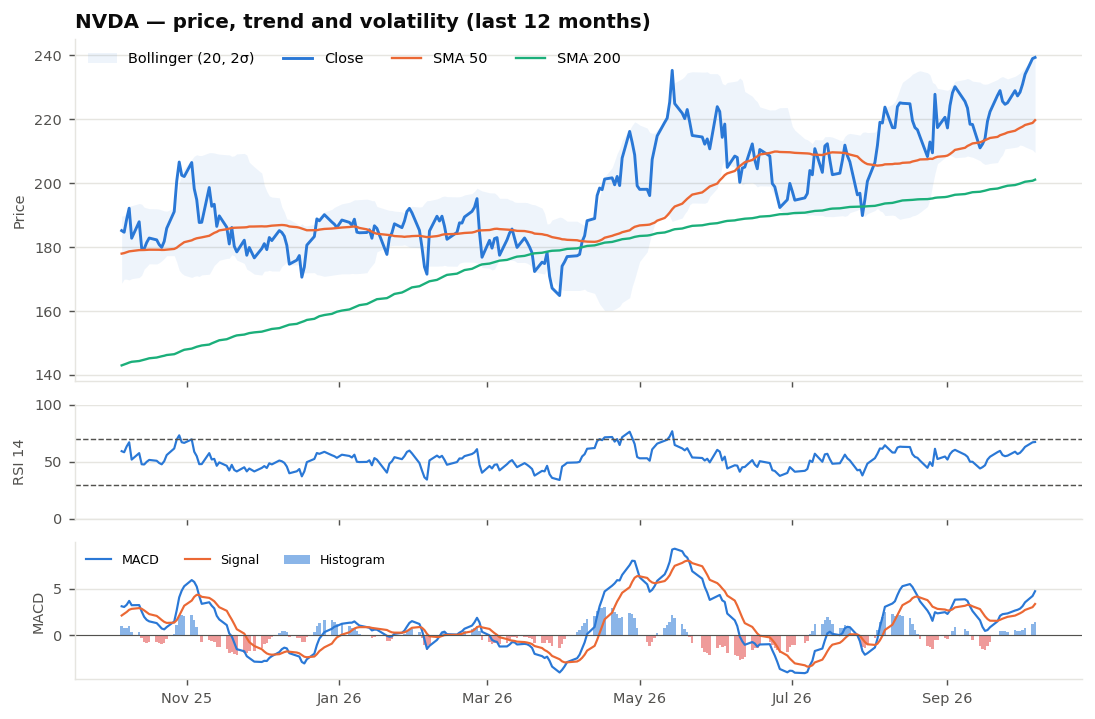
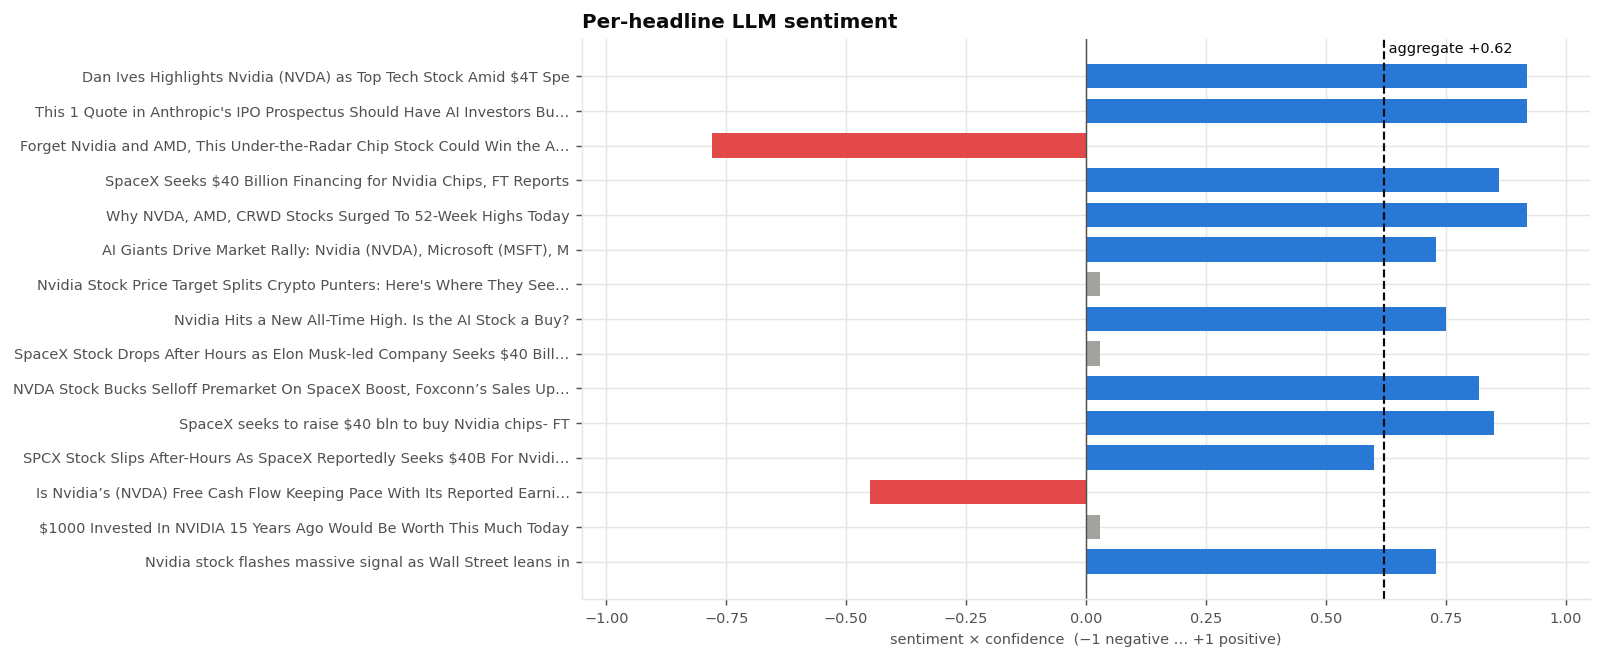

In [22]:
# The styled, self-contained HTML brief (charts embedded as base64), rendered inline.
# Open outputs/brief.html in a browser for the full-page version.
display(HTML(open(paths["html"], encoding="utf-8").read()))

## Appendix — design notes
* **Why Wilder RSI?** It is the original definition used by trading platforms; a rolling-mean RSI is a
  different indicator (Section 3.1 shows the divergence on this very series).
* **Why confidence-weighted sentiment?** A low-confidence negative should not cancel a high-confidence
  positive; failed validations are excluded, not imputed.
* **How is LLM output guaranteed valid?** JSON mode → fence/prose-tolerant extraction → Pydantic
  validation → bounded repair loop with the error fed back → `None` + exclusion. Every attempt is
  audited (`outputs/llm_calls.jsonl`).
* **Graceful degradation:** with no API key, sentiment is reported as *unavailable* and the signal falls
  back to a clearly-flagged rule-based vote, so the report still renders.
* **Known limits:** no fundamentals/macro in the signal; yfinance is a scraped, rate-limited source;
  free-tier LLM latency bounds headline count (`MAX_HEADLINES=15`).